# Lab 1 DS & AI - DQ
# Influence of Data Quality on Machine Learning performance

**Group:** _8_ 

**Names / student numbers:** 

_Luís Forti - 3981932_

_Marcell Slyuch - 3992616_

_Ntando Thato Mazinyane - 3987639_

In this lab we will explore different data quality problems and their possible effect on classification or regression tasks. To help you to start quickly with this lab, the notebook below already implements a basic Regression and Classification task. You can do the exercises by taking this code and modify/extend it. 

## Import Relevant Libraries

In [1]:
# Uncomment if needed and restart the Kernel after installation
# %pip install seaborn
# %pip install scipy
# %pip install scikit-learn

In [2]:
# If you get an error on the import of the seaborn package below, then you need to install
# it first with 'pip' in the above box. Uncomment the '%pip' line, execute the cell, comment it again,
# and do a restart of the kernel (top Menu bar, menu 'Kernel', menu-item 'Restart Kernel'

import matplotlib.pyplot as plt
from scipy.io import arff
import seaborn as sns
import pandas as pd
import warnings
import os
import random

warnings.filterwarnings("ignore", module=r"matplotlib\..*")

## Load Data
Some files are stored as an arff file, for which you can use the function below to load it into a pandas dataframe. An ARFF file can be viewed with a text editor; please do because it often contains documentation among other things about the meaning of the various attributes.

In [3]:
def load_arff(file_path):
    '''Return a pandas dataframe and meta data from an arff file.'''
    ar, meta = arff.loadarff(file_path)
    return pd.DataFrame(ar), meta

# Classification
---
We will work with a credit approval dataset, where the goal is to classify whether a credit will be approved or not based on several input variables.

### Load the Data
Let's load in some data with which we will try to perform a classification on and print its meta data information to get a first overview.

In [4]:
# The dataset may be located in different places depending on your setup.
# We try a few common locations and use the first one that exists.
candidate_locations = [
    "credit-a.arff",                                                    # same folder as the notebook
    os.path.join("Datasets", "Datasets", "uci-large", "credit-a.arff"), # original lab layout
    os.path.join("Datasets", "uci-large", "credit-a.arff"),
    os.path.join("uci-large", "credit-a.arff"),
]

path = next((p for p in candidate_locations if os.path.exists(p)), None)
if path is None:
    raise FileNotFoundError("credit-a.arff not found - adjust 'candidate_locations' to point to the file.")

# Load the arff file and print the meta information
data, meta = load_arff(path)
print(meta)

Dataset: credit-rating
	A1's type is nominal, range is ('b', 'a')
	A2's type is numeric
	A3's type is numeric
	A4's type is nominal, range is ('u', 'y', 'l', 't')
	A5's type is nominal, range is ('g', 'p', 'gg')
	A6's type is nominal, range is ('c', 'd', 'cc', 'i', 'j', 'k', 'm', 'r', 'q', 'w', 'x', 'e', 'aa', 'ff')
	A7's type is nominal, range is ('v', 'h', 'bb', 'j', 'n', 'z', 'dd', 'ff', 'o')
	A8's type is numeric
	A9's type is nominal, range is ('t', 'f')
	A10's type is nominal, range is ('t', 'f')
	A11's type is numeric
	A12's type is nominal, range is ('t', 'f')
	A13's type is nominal, range is ('g', 'p', 's')
	A14's type is numeric
	A15's type is numeric
	class's type is nominal, range is ('+', '-')



## Data Preparation
Lets take a deeper look at the data and see if we can make some interesting observations.

In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 690 entries, 0 to 689
Data columns (total 16 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   A1      690 non-null    object 
 1   A2      678 non-null    float64
 2   A3      690 non-null    float64
 3   A4      690 non-null    object 
 4   A5      690 non-null    object 
 5   A6      690 non-null    object 
 6   A7      690 non-null    object 
 7   A8      690 non-null    float64
 8   A9      690 non-null    object 
 9   A10     690 non-null    object 
 10  A11     690 non-null    float64
 11  A12     690 non-null    object 
 12  A13     690 non-null    object 
 13  A14     677 non-null    float64
 14  A15     690 non-null    float64
 15  class   690 non-null    object 
dtypes: float64(6), object(10)
memory usage: 86.4+ KB


Here we can already observe that there exist some Null values in the table. Column `A2` and `A14` apparently have some null values (less non null values than the other columns). 
In this case we will deal with the null values by dropping them from the dataset.

In [6]:
# remove all Nan values
data.dropna(inplace=True)

We will now take a look inside the data with the first 5 rows.

In [7]:
data.head()

,A1,A2,A3,A4,A5,A6,A7,A8,A9,A10,A11,A12,A13,A14,A15,class
0,b'b',30.83,0.000,b'u',b'g',b'w',b'v',1.25,b't',b't',1.0,b'f',b'g',202.0,0.0,b'+'
1,b'a',58.67,4.460,b'u',b'g',b'q',b'h',3.04,b't',b't',6.0,b'f',b'g',43.0,560.0,b'+'
2,b'a',24.50,0.500,b'u',b'g',b'q',b'h',1.50,b't',b'f',0.0,b'f',b'g',280.0,824.0,b'+'
3,b'b',27.83,1.540,b'u',b'g',b'w',b'v',3.75,b't',b't',5.0,b't',b'g',100.0,3.0,b'+'
4,b'b',20.17,5.625,b'u',b'g',b'w',b'v',1.71,b't',b'f',0.0,b'f',b's',120.0,0.0,b'+'


We can observe that the nominal features are stored as an byte object (prefixed with a b like `b'a'`) . It is possible to convert the byte data type with the `decode()` function to strings.

In [8]:
# save which columns are nominal
nominal = []

for col, typ in zip(data.columns, data.dtypes):
    if(typ == 'object'):
        # Decode the byte object for the whole column
        data[col] = data[col].map(lambda x: x.decode())
        # remember the nominal column for later
        nominal.append(col)
        
data.head()

,A1,A2,A3,A4,A5,A6,A7,A8,A9,A10,A11,A12,A13,A14,A15,class
0,b,30.83,0.000,u,g,w,v,1.25,t,t,1.0,f,g,202.0,0.0,+
1,a,58.67,4.460,u,g,q,h,3.04,t,t,6.0,f,g,43.0,560.0,+
2,a,24.50,0.500,u,g,q,h,1.50,t,f,0.0,f,g,280.0,824.0,+
3,b,27.83,1.540,u,g,w,v,3.75,t,t,5.0,t,g,100.0,3.0,+
4,b,20.17,5.625,u,g,w,v,1.71,t,f,0.0,f,s,120.0,0.0,+


We will be working with a Naive Bayes classifier, but this ML method can only receive numerical data as its input. Therefore, we need to translate our nominal data to numeric. Because we have nominal data that does not have any ordering, we can apply **one hot encoding** to the nominal data. The pandas library contains the `get_dummies()` function that helps us to create these one hot encodings for nominal variables.

In [9]:
# Exclude the class label variable
nominal = nominal[0:-1]
# Show how the one hot encoding looks
pd.get_dummies(data[nominal[0]])

,?,a,b
0,False,False,True
1,False,True,False
2,False,True,False
3,False,False,True
4,False,False,True
...,...,...,...
685,False,False,True
686,False,True,False
687,False,True,False
688,False,False,True


In [10]:
# create one hot encoding for all variables
dummies = pd.get_dummies(data[nominal])
# Concatenate with df and drop nominal columns
data = pd.concat([data, dummies], axis=1).drop(nominal, axis=1)

# remove the the encodings that end with ? since they contain only 0
data.drop([col for col in data.columns if col.endswith('_?')], axis=1, inplace=True)
data.head()

,A2,A3,A8,A11,A14,A15,class,A1_a,A1_b,A4_l,...,A7_z,A9_f,A9_t,A10_f,A10_t,A12_f,A12_t,A13_g,A13_p,A13_s
0,30.83,0.000,1.25,1.0,202.0,0.0,+,False,True,False,...,False,False,True,False,True,True,False,True,False,False
1,58.67,4.460,3.04,6.0,43.0,560.0,+,True,False,False,...,False,False,True,False,True,True,False,True,False,False
2,24.50,0.500,1.50,0.0,280.0,824.0,+,True,False,False,...,False,False,True,True,False,True,False,True,False,False
3,27.83,1.540,3.75,5.0,100.0,3.0,+,False,True,False,...,False,False,True,False,True,False,True,True,False,False
4,20.17,5.625,1.71,0.0,120.0,0.0,+,False,True,False,...,False,False,True,True,False,True,False,False,False,True


After the one hot encoding, our dataframe contains 47 columns.

In [11]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 666 entries, 0 to 689
Data columns (total 47 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   A2      666 non-null    float64
 1   A3      666 non-null    float64
 2   A8      666 non-null    float64
 3   A11     666 non-null    float64
 4   A14     666 non-null    float64
 5   A15     666 non-null    float64
 6   class   666 non-null    object 
 7   A1_a    666 non-null    bool   
 8   A1_b    666 non-null    bool   
 9   A4_l    666 non-null    bool   
 10  A4_u    666 non-null    bool   
 11  A4_y    666 non-null    bool   
 12  A5_g    666 non-null    bool   
 13  A5_gg   666 non-null    bool   
 14  A5_p    666 non-null    bool   
 15  A6_aa   666 non-null    bool   
 16  A6_c    666 non-null    bool   
 17  A6_cc   666 non-null    bool   
 18  A6_d    666 non-null    bool   
 19  A6_e    666 non-null    bool   
 20  A6_ff   666 non-null    bool   
 21  A6_i    666 non-null    bool   
 22  A6_j   

In [12]:
# List of all the columns in our data, remove class variable
col = list(data.columns)
col.remove('class')
print(f'All Features:\n {col} \n', 110*'-')

# Select all or a subset of the input features
input_features = col[0:]
print(f'Input Features:\n {input_features}')

All Features:
 ['A2', 'A3', 'A8', 'A11', 'A14', 'A15', 'A1_a', 'A1_b', 'A4_l', 'A4_u', 'A4_y', 'A5_g', 'A5_gg', 'A5_p', 'A6_aa', 'A6_c', 'A6_cc', 'A6_d', 'A6_e', 'A6_ff', 'A6_i', 'A6_j', 'A6_k', 'A6_m', 'A6_q', 'A6_r', 'A6_w', 'A6_x', 'A7_bb', 'A7_dd', 'A7_ff', 'A7_h', 'A7_j', 'A7_n', 'A7_o', 'A7_v', 'A7_z', 'A9_f', 'A9_t', 'A10_f', 'A10_t', 'A12_f', 'A12_t', 'A13_g', 'A13_p', 'A13_s'] 
 --------------------------------------------------------------------------------------------------------------
Input Features:
 ['A2', 'A3', 'A8', 'A11', 'A14', 'A15', 'A1_a', 'A1_b', 'A4_l', 'A4_u', 'A4_y', 'A5_g', 'A5_gg', 'A5_p', 'A6_aa', 'A6_c', 'A6_cc', 'A6_d', 'A6_e', 'A6_ff', 'A6_i', 'A6_j', 'A6_k', 'A6_m', 'A6_q', 'A6_r', 'A6_w', 'A6_x', 'A7_bb', 'A7_dd', 'A7_ff', 'A7_h', 'A7_j', 'A7_n', 'A7_o', 'A7_v', 'A7_z', 'A9_f', 'A9_t', 'A10_f', 'A10_t', 'A12_f', 'A12_t', 'A13_g', 'A13_p', 'A13_s']


## Model Training: Classification
Now that we have looked at the data, it is time to define our regression tasks. We would like to predict the credit approval given our different input features. Therefore, our class label y will be the `'class'` column, which as we could see before encodes the approval binary as `+` or `-`.  

In [13]:
# Seperate the input features from the class labels
X = data[input_features]
y = data['class']

### Train and Test Split
Before moving on, we need to split the data into train and test subsets. 

In [14]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.7,
                                                    test_size=0.3,
                                                    random_state=100)

### Train the Naive Bayes Classifier
The model we choose here is a gaussian naive bayes classifier with default settings.

In [15]:
from sklearn.naive_bayes import GaussianNB
 
# Define the model
classifier = GaussianNB()
 
# Fit data to the classifier
classifier.fit(X_train, y_train)

,priors,None
,var_smoothing,1e-09


## Model Evaluation: Classification
For the evaluation of our classification model, we will look at the **precision**, **recall** and **f1-score**. Additionally, we will plot the **confusion matrix**. 

In [16]:
# Importing required modules
from sklearn.metrics import classification_report, confusion_matrix


def evaluate_classification(y_test, y_pred):
    # Print the standart evaluation metrics
    class_report = classification_report(y_test, y_pred)
    print(class_report)
    # Plot the confusion matrix
    plt.figure(figsize=(7,5))
    plt.title("Confusion Matrix", fontsize=18)
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True)
    
    return class_report, cm

              precision    recall  f1-score   support

           +       0.82      0.80      0.81        93
           -       0.83      0.85      0.84       107

    accuracy                           0.82       200
   macro avg       0.82      0.82      0.82       200
weighted avg       0.82      0.82      0.82       200



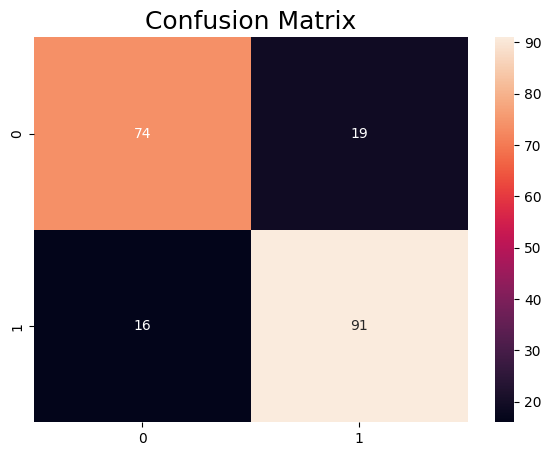

In [17]:
# Get the predictions from the classifier
y_pred = classifier.predict(X_test)

# Evaluate the classifier
class_report, conf_mat = evaluate_classification(y_test, y_pred)

---
# Exercise 3 &mdash; [Easy] Experiment: "Bias in the data"

**Aim.** *"Bias in the data creates bias in the model."* We test how strong that effect
is. `credit-a` is anonymised; the guessed meaning of **`A1`** is *gender* (values `a`
and `b`). We build training sets whose group composition is deliberately skewed and see
how the model then performs **for each group separately** and **overall**.

**Set-up.**

* Split the data by `A1`: **group A** = rows with `A1 = a`, **group B** = rows with
  `A1 = b`. Within each group, keep **20 % as a test set** and **80 % for training**.
  This gives an *A test set*, a *B test set*, and their union, the *combined test set* &mdash;
  all fixed and untouched throughout.
* The **basis training set** is the 80 % training rows of group A only (so it starts
  100 % group A). For a bias ratio `p`, **replace `p` % of it with randomly chosen
  group-B training rows**, keeping the training-set size constant.
  * `p = 0`  &rarr; training is 100 % group A (maximally skewed toward A).
  * `p = 0.5` &rarr; training is half A, half B (balanced).
* Sweep `p` over `0, 5, 10, 20, 30, 40, 50 %`. At each `p`, train a Gaussian Naive
  Bayes classifier and record accuracy on the **A test set**, the **B test set**, and
  the **combined test set**.
* Plot the three curves against `p`, plus the **disparity** `|acc_A - acc_B|`.

**What we expect.** At `p = 0` the model should do well on the A test set and poorly on
the B test set (it never saw group B). As group B enters the training data, B-test
accuracy should rise, A-test accuracy should stay roughly flat or dip slightly, the
combined accuracy should rise, and the disparity should shrink &mdash; i.e. the group
imbalance in the data becomes a performance gap in the model.

**Points.** 4 for the `A1` experiment; 2 more for repeating it on an attribute with
more than two values (Part 2 below).

## Reusable pipeline

A clean, un-encoded copy of the data and the baseline one-hot encoding. We encode **once**, on the whole (filtered) dataset, so every train/test subset shares the same columns.

In [18]:
import numpy as np
from sklearn.metrics import accuracy_score, f1_score

_raw_arff, _meta = load_arff(path)
RAW = _raw_arff.dropna().reset_index(drop=True)

def _decode_if_bytes(v):
    return v.decode() if isinstance(v, bytes) else v

for _c in RAW.columns:
    if not pd.api.types.is_numeric_dtype(RAW[_c]):
        RAW[_c] = RAW[_c].map(_decode_if_bytes)

NOMINAL_ALL = [c for c in RAW.columns
               if not pd.api.types.is_numeric_dtype(RAW[c]) and c != "class"]


def encode(df):
    """Baseline one-hot encoding: dummies for every nominal column, '_?' dummies
    dropped. Returns (X, y); the original index of df is preserved."""
    dummies = pd.get_dummies(df[NOMINAL_ALL])
    enc = pd.concat([df, dummies], axis=1).drop(columns=NOMINAL_ALL)
    enc = enc.drop(columns=[c for c in enc.columns if c.endswith("_?")])
    feats = [c for c in enc.columns if c != "class"]
    return enc[feats], enc["class"]

print(f"{len(RAW)} rows.  A1:", dict(RAW["A1"].value_counts()))

666 rows.  A1: {'b': 451, 'a': 203, '?': 12}


## The experiment as a function

`run_bias_experiment` builds the fixed per-group test sets, then sweeps the bias ratio, each time rebuilding the training set (constant size) with a `p` fraction of group-B rows swapped in and retraining.

In [19]:
def run_bias_experiment(bias_attr, a_value, b_value="*", keep_values=None,
                        ratios=(0.0, 0.05, 0.10, 0.20, 0.30, 0.40, 0.50),
                        test_size=0.20, n_repeats=40, seed=0, min_rows=25):
    """Bias experiment for one attribute.

    bias_attr   : column to split on (e.g. 'A1')
    a_value     : the 'basis' group; training starts 100% from this group
    b_value     : group(s) mixed in -- a single value, or '*' for 'all other kept values'
    keep_values : restrict the analysis to these attribute values (default: all with
                  >= min_rows rows, ignoring '?')

    Returns (results_df, categories). results_df has one row per (ratio, repeat) with
    acc_<value> for every kept category plus acc_combined and disparity_AB.
    """
    from sklearn.model_selection import train_test_split

    sub = RAW[RAW[bias_attr] != "?"].copy()
    if keep_values is None:
        vc = sub[bias_attr].value_counts()
        keep_values = sorted(vc.index[vc >= min_rows])
    sub = sub[sub[bias_attr].isin(keep_values)]
    X, y = encode(sub)                                   # encode once -> shared columns

    # fixed 80/20 split of indices within each kept category
    tr, te = {}, {}
    for v in keep_values:
        idx = sub.index[sub[bias_attr] == v].to_numpy()
        tr[v], te[v] = train_test_split(idx, test_size=test_size, random_state=seed)

    A_train = tr[a_value]
    if b_value == "*":
        B_train = np.concatenate([tr[v] for v in keep_values if v != a_value])
    else:
        B_train = tr[b_value]
    combined_test = np.concatenate([te[v] for v in keep_values])
    n_total = len(A_train)

    rng = np.random.default_rng(seed)
    rows = []
    for p in ratios:
        for r in range(1 if p == 0.0 else n_repeats):
            n_b = int(round(p * n_total))
            pick_a = rng.choice(A_train, size=n_total - n_b, replace=False)
            pick_b = rng.choice(B_train, size=n_b, replace=n_b > len(B_train))
            tri = np.concatenate([pick_a, pick_b])

            model = GaussianNB().fit(X.loc[tri], y.loc[tri])
            rec = {"ratio": p, "repeat": r}
            for v in keep_values:
                rec[f"acc_{v}"] = accuracy_score(y.loc[te[v]], model.predict(X.loc[te[v]]))
            rec["acc_combined"] = accuracy_score(y.loc[combined_test],
                                                 model.predict(X.loc[combined_test]))
            rec["disparity_AB"] = abs(rec[f"acc_{a_value}"] -
                                      (rec[f"acc_{b_value}"] if b_value != "*"
                                       else np.mean([rec[f"acc_{v}"] for v in keep_values
                                                     if v != a_value])))
            rows.append(rec)
    return pd.DataFrame(rows), keep_values


def summarise(df):
    return df.drop(columns="repeat").groupby("ratio").agg(["mean", "min", "max"])

def display_summary_table(df):
    from IPython.display import display, HTML
    
    s = summarise(df)

    # Get metrics and statistics directly from the MultiIndex
    metrics = s.columns.get_level_values(0).unique()
    stats = s.columns.get_level_values(1).unique()

    html = """
    <table>
    <thead>
    <tr>
        <th rowspan="2">ratio</th>
    """

    # First header row: metric names spanning their statistics
    for metric in metrics:
        html += (
            f'<th colspan="{len(stats)}" style="text-align:center">'
            f'{metric}</th>'
        )

    html += "</tr><tr>"

    # Second header row: statistics
    for metric in metrics:
        for stat in stats:
            html += f"<th>{stat}</th>"

    html += "</tr></thead><tbody>"

    # Data rows
    for index in s.index:
        html += f"<tr><td>{index:.2f}</td>"

        for metric in metrics:
            for stat in stats:
                value = s.loc[index, (metric, stat)]
                html += f"<td>{value:.3f}</td>"

        html += "</tr>"

    html += """
    </tbody>
    </table>
    """

    display(HTML(html))


def plot_bias(df, cats, a_value, title):
    s = summarise(df)
    x = s.index.to_numpy() * 100
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

    for v in cats:
        col = f"acc_{v}"
        ax1.plot(x, s[(col, "mean")], marker="o",
                 label=f"{v} test set" + ("  (basis group A)" if v == a_value else ""))
        ax1.fill_between(x, s[(col, "min")], s[(col, "max")], alpha=0.12)
    ax1.plot(x, s[("acc_combined", "mean")], marker="s", color="black", lw=2,
             label="combined test set")
    ax1.axvline(0, ls=":", c="grey")
    ax1.set_xlabel("bias ratio p  (% of the training set replaced by group-B rows)")
    ax1.set_ylabel("accuracy")
    ax1.set_title(title)
    ax1.grid(alpha=0.3); ax1.legend(fontsize=8)

    ax2.plot(x, s[("disparity_AB", "mean")], marker="o", color="tab:red")
    ax2.fill_between(x, s[("disparity_AB", "min")], s[("disparity_AB", "max")],
                     color="tab:red", alpha=0.15)
    ax2.set_xlabel("bias ratio p  (%)")
    ax2.set_ylabel("|acc(group A) - acc(group B)|")
    ax2.set_title("Performance disparity between the groups")
    ax2.grid(alpha=0.3)
    plt.tight_layout(); plt.show()

## Part 1 &mdash; `A1` (presumed *gender*), groups `a` and `b`  &nbsp;[4 points]

In [20]:
res_a1, cats_a1 = run_bias_experiment("A1", a_value="a", b_value="b",
                                      n_repeats=40, seed=0)
display_summary_table(res_a1)

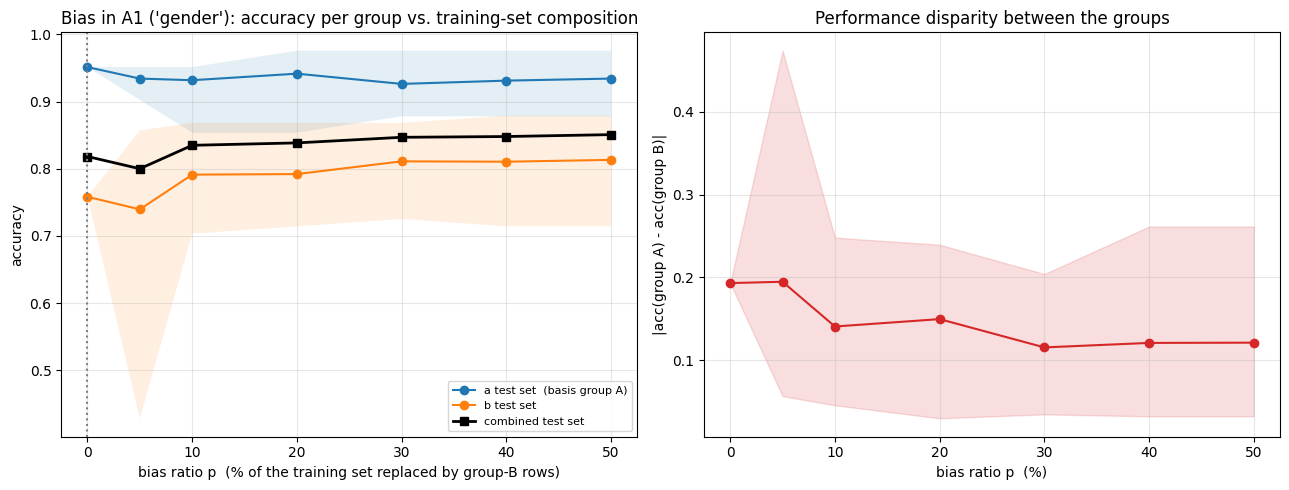

In [21]:
plot_bias(res_a1, cats_a1, "a", "Bias in A1 (\'gender\'): accuracy per group vs. training-set composition")

## Part 2 &mdash; `A13` (values `g`, `s`, `p`)  &nbsp;[2 points]

`A13` has **three** categories. After dropping rows with missing values their counts are
`g` = 609, `s` = 55, `p` = **2**. All three are kept and each gets its own test set, but
note that `p`'s test set is a **single row**, so its curve is essentially noise &mdash; it
is shown for completeness, not as a reliable measurement.

Group **A** (the basis training group) is the smaller usable category `s`; group **B**
(mixed in) is `g`. `disparity_AB` is measured between `s` and `g` only.

_(To follow the assignment's `A4` example literally: `bias_attr="A4"`, `a_value="y"`, `b_value="u"`.)_

In [22]:
res_a13, cats_a13 = run_bias_experiment("A13", a_value="s", b_value="*",
                                        keep_values=["g", "s", "p"],
                                        n_repeats=80, seed=42)
print("categories:", cats_a13,
      " row counts:", {v: int((RAW["A13"] == v).sum()) for v in cats_a13})
display_summary_table(res_a13)

categories: ['g', 's', 'p']  row counts: {'g': 609, 's': 55, 'p': 2}


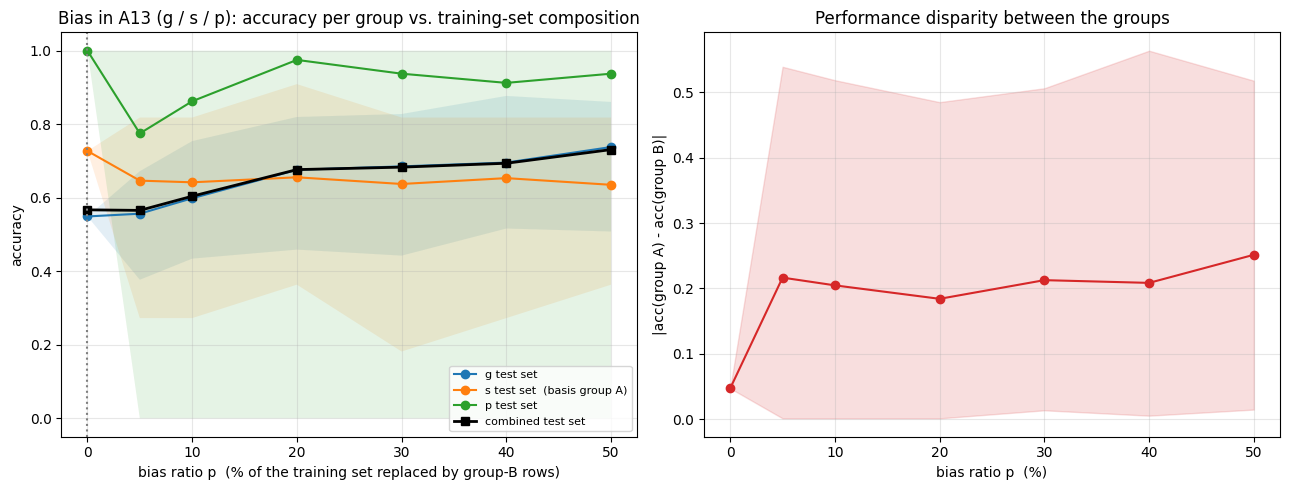

In [23]:
plot_bias(res_a13, cats_a13, "s",
          "Bias in A13 (g / s / p): accuracy per group vs. training-set composition")